# Лабораторная работа №3

## Выполнил студент: Черкасов Александр Андреевич, ИВТб-2301

### Вариант 24

In [11]:
import numpy as np
import matplotlib.pyplot as plot
from IPython.display import display, Markdown

def md(s: str) -> None:
    display(Markdown(s))

## 1. По таблице с неравноотстоящими значениями аргумента выполнить интерполяцию, используя формулу Лагранжа. Точность E<=0.000001.

Задание: $X = 0.665$
    
| $X$ | $Y$ |
|-----|---------|
| 0.41| 2.57418 |
| 0.46| 2.32513 |
| 0.52| 2.09336 |
| 0.60| 1.86203 |
| 0.65| 1.74926 |
| 0.72| 1.62098 |

In [12]:
x_data1 = np.array([0.41, 0.46, 0.52, 0.60, 0.65, 0.72], dtype=float)
y_data1 = np.array([2.57418, 2.32513, 2.09336, 1.86203, 1.74926, 1.62098], dtype=float)
X_target1 = 0.665

def lagrange_interpolation(x, x_data, y_data):
    n = len(x_data)
    result = 0.0
    for i in range(n):
        term = y_data[i]
        for j in range(n):
            if i != j:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += term
    return result

y_res1 = lagrange_interpolation(X_target1, x_data1, y_data1)
md(f"Значение интерполяционного многочлена Лагранжа в точке X = {X_target1}: **{y_res1:.6f}**")

Значение интерполяционного многочлена Лагранжа в точке X = 0.665: **1.719172**

## 2. По таблице с равноотстоящими значениями аргумента вычислить значения функции для заданных значений аргументов, используя первую и вторую формулы Ньютона. Точность E<=0.000001.

Задание:
$X_1 = 0.1873$; $X_2 = 0.2326$; $X_3 = 0.1783$; $X_4 = 0.2450$

| $X$   | $Y$     |
|-------|---------|
| 0.180 | 5.61543 |
| 0.185 | 5.46698 |
| 0.190 | 5.32634 |
| 0.195 | 5.19304 |
| 0.200 | 5.06649 |
| 0.205 | 4.94619 |
| 0.210 | 4.83170 |
| 0.215 | 4.72261 |
| 0.220 | 4.61855 |
| 0.225 | 4.51912 |
| 0.230 | 4.42422 |
| 0.235 | 4.33337 |

In [13]:
x_data2 = np.array([0.180, 0.185, 0.190, 0.195, 0.200, 0.205, 0.210, 0.215, 0.220, 0.225, 0.230, 0.235], dtype=float)
y_data2 = np.array([5.61543, 5.46698, 5.32634, 5.19304, 5.06649, 4.94619, 4.83170, 4.72261, 4.61855, 4.51912, 4.42422, 4.33337], dtype=float)
X_targets2 = [0.1873, 0.2326, 0.1783, 0.2450]

# Таблица конечных разностей
def diff_table(y_data):
    n = len(y_data)
    table = np.zeros((n, n))
    table[:, 0] = y_data
    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = table[i+1][j-1] - table[i][j-1]
    return table

dt = diff_table(y_data2)

# Первая формула Ньютона (для начала таблицы)
def newton_forward(x, x_data, dt):
    n = len(x_data)
    h = x_data[1] - x_data[0]
    t = (x - x_data[0]) / h
    result = dt[0, 0]
    t_term = 1.0
    fact = 1.0
    for i in range(1, n):
        t_term *= (t - i + 1)
        fact *= i
        result += (t_term * dt[0, i]) / fact
    return result

# Вторая формула Ньютона (для конца таблицы)
def newton_backward(x, x_data, dt):
    n = len(x_data)
    h = x_data[1] - x_data[0]
    t = (x - x_data[-1]) / h
    result = dt[-1, 0]
    t_term = 1.0
    fact = 1.0
    for i in range(1, n):
        t_term *= (t + i - 1)
        fact *= i
        result += (t_term * dt[n - 1 - i, i]) / fact
    return result

mean_x = np.mean(x_data2)
for target in X_targets2:
    if target <= mean_x:
        res = newton_forward(target, x_data2, dt)
        md(f"В точке $X = {target}$ (ближе к началу, используем **первую** формулу Ньютона): **$Y = {res:.6f}$**")
    else:
        res = newton_backward(target, x_data2, dt)
        md(f"В точке $X = {target}$ (ближе к концу, используем **вторую** формулу Ньютона): **$Y = {res:.6f}$**")


В точке $X = 0.1873$ (ближе к началу, используем **первую** формулу Ньютона): **$Y = 5.401342$**

В точке $X = 0.2326$ (ближе к концу, используем **вторую** формулу Ньютона): **$Y = 4.376700$**

В точке $X = 0.1783$ (ближе к началу, используем **первую** формулу Ньютона): **$Y = 5.668013$**

В точке $X = 0.245$ (ближе к концу, используем **вторую** формулу Ньютона): **$Y = 4.012270$**

## 3. Выбор эмпирической зависимости и среднеквадратичное приближение (метод наименьших квадратов)

Задание:
| $X$ | $Y$ |
|-----|-----|
| 4.0 | 64  |
| 4.1 | 73  |
| 4.2 | 85  |
| 4.3 | 97  |
| 4.4 | 112 |
| 4.5 | 128 |

### Сравнение моделей:

Сума квадратов ошибок (SSE) для линейной модели: 26.8190

Сума квадратов ошибок (SSE) для квадратичной модели: 0.5214

Сума квадратов ошибок (SSE) для экспоненциальной модели: 0.7796

Видно, что минимальная ошибка достигнута при **квадратичной** зависимости.

Уравнение: $y = 83.9286 x^2 + (-585.1071) x + (1061.4643)$

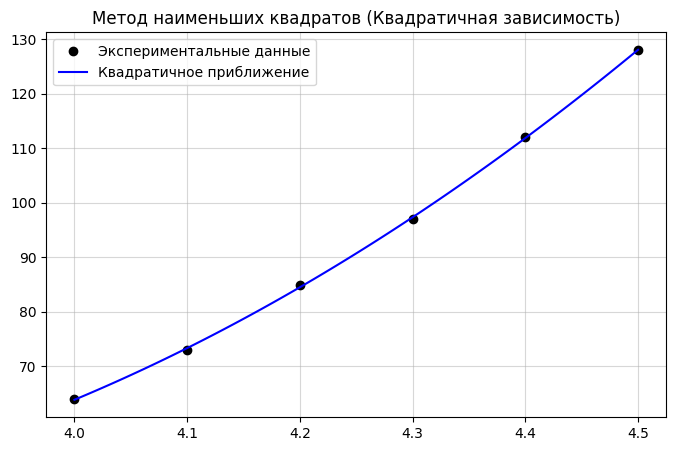

In [14]:
x_data3 = np.array([4.0, 4.1, 4.2, 4.3, 4.4, 4.5], dtype=float)
y_data3 = np.array([64, 73, 85, 97, 112, 128], dtype=float)

# Линейная зависимость y = ax + b
coeffs_lin = np.polyfit(x_data3, y_data3, 1)
y_lin = np.polyval(coeffs_lin, x_data3)
sse_lin = np.sum((y_data3 - y_lin)**2)

# Квадратичная зависимость y = ax^2 + bx + c
coeffs_quad = np.polyfit(x_data3, y_data3, 2)
y_quad = np.polyval(coeffs_quad, x_data3)
sse_quad = np.sum((y_data3 - y_quad)**2)

# Экспоненциальная зависимость y = a * e^(bx)  ->  ln(y) = ln(a) + bx
coeffs_exp = np.polyfit(x_data3, np.log(y_data3), 1)
a_exp = np.exp(coeffs_exp[1])
b_exp = coeffs_exp[0]
y_exp = a_exp * np.exp(b_exp * x_data3)
sse_exp = np.sum((y_data3 - y_exp)**2)

md("### Сравнение моделей:")
md(f"Сума квадратов ошибок (SSE) для линейной модели: {sse_lin:.4f}")
md(f"Сума квадратов ошибок (SSE) для квадратичной модели: {sse_quad:.4f}")
md(f"Сума квадратов ошибок (SSE) для экспоненциальной модели: {sse_exp:.4f}")

md("Видно, что минимальная ошибка достигнута при **квадратичной** зависимости.")
md(f"Уравнение: $y = {coeffs_quad[0]:.4f} x^2 + ({coeffs_quad[1]:.4f}) x + ({coeffs_quad[2]:.4f})$")

plot.figure(figsize=(8, 5))
plot.plot(x_data3, y_data3, 'ko', label='Экспериментальные данные')
x_plot = np.linspace(4.0, 4.5, 100)
plot.plot(x_plot, np.polyval(coeffs_quad, x_plot), 'b-', label='Квадратичное приближение')
plot.legend()
plot.grid(True, alpha=0.5)
plot.title("Метод наименьших квадратов (Квадратичная зависимость)")
plot.show()


## 4. Проверка результатов (Использование Scipy)

In [15]:
import scipy.interpolate as interp

md("### Проверка Задачи 1 (Лагранж)")
poly_lagrange = interp.lagrange(x_data1, y_data1)
res_scipy1 = poly_lagrange(X_target1)
md(f"Scipy Лагранж: {res_scipy1:.6f}, наше решение: {y_res1:.6f}")

md("### Проверка Задачи 2 (Ньютон/BarycentricInterpolator)")
bary_interp = interp.BarycentricInterpolator(x_data2, y_data2)
for target in X_targets2:
    res_sp = bary_interp(target)
    md(f"В точке {target} интерполированное значение scipy = {res_sp:.6f}")

### Проверка Задачи 1 (Лагранж)

Scipy Лагранж: 1.719172, наше решение: 1.719172

### Проверка Задачи 2 (Ньютон/BarycentricInterpolator)

В точке 0.1873 интерполированное значение scipy = 5.401342

В точке 0.2326 интерполированное значение scipy = 4.376700

В точке 0.1783 интерполированное значение scipy = 5.668013

В точке 0.245 интерполированное значение scipy = 4.012270